# Analyzing Wikipedia Pages

In this project, we will analyze Wikipedia pages to gain insights into the content and structure of the articles. We will use Python and various libraries to scrape and process the data, and then visualize the results to better understand the Wikipedia ecosystem. We will implement a quick script command to collect 1000 MB worth of data for our processing. For reference, the below script was generated by Claude AI as the course hasn't reached webscraping as of yet. Using the script, we generated 6648 files, which are otherwise found in the `wiki` folder in this directory.

In [1]:
import os, time, requests
from urllib.parse import quote

# --- settings ---
OUT_DIR   = 'wiki'
TARGET_MB = 1000      # stop once the folder reaches this size
DELAY     = 0.3      # seconds between requests
# ----------------

HEADERS = {'User-Agent': 'grep-practice/1.0 (learning project)'}
API = 'https://en.wikipedia.org/w/api.php'
os.makedirs(OUT_DIR, exist_ok=True)

def folder_bytes():
    return sum(os.path.getsize(os.path.join(OUT_DIR, f))
               for f in os.listdir(OUT_DIR))

def random_titles(n=50):
    r = requests.get(API, headers=HEADERS, timeout=30, params={
        'action': 'query', 'list': 'random',
        'rnnamespace': 0, 'rnlimit': n, 'format': 'json'})
    r.raise_for_status()
    return [p['title'] for p in r.json()['query']['random']]

target = TARGET_MB * 1_000_000
total  = folder_bytes()
new    = 0
print(f'starting at {total/1e6:.1f} MB, target {TARGET_MB} MB')

try:
    while total < target:
        for title in random_titles():
            if total >= target:
                break
            slug = quote(title.replace(' ', '_'), safe='')
            path = os.path.join(OUT_DIR, slug + '.html')
            if os.path.exists(path):
                continue
            try:
                r = requests.get(f'https://en.wikipedia.org/wiki/{slug}',
                                 headers=HEADERS, timeout=30)
                if r.status_code != 200:
                    continue
            except requests.RequestException:
                continue
            with open(path, 'w', encoding='utf-8') as f:
                f.write(r.text)
            total += os.path.getsize(path)
            new += 1
            if new % 25 == 0:
                print(f'{total/1e6:6.1f} MB   {new} new files', end='\r')
            time.sleep(DELAY)
except KeyboardInterrupt:
    print('\ninterrupted')

print(f'\ndone: {len(os.listdir(OUT_DIR))} files, {folder_bytes()/1e6:.1f} MB')

starting at 1000.0 MB, target 1000 MB

done: 6648 files, 1000.0 MB


We can now begin analyzing the collected Wikipedia pages to gain insights into the content and structure of the articles. We will use Python and various libraries to process the data, and then visualize the results to better understand the Wikipedia ecosystem. The first segment of the task is to check if we can actually read the contents of the folder, and if we can ready any of the files.

In [2]:
import os
files = os.listdir("wiki")

print(f"---- File Directory -----\n"
      f"The number of files in this directory is {len(files)}, which is too many to show. We will show the first 10 of {len(files)} files, and the sample content of the first file.\n")

for i in range(10):
    print(f"{i+1}. {files[i]}")

print(f"\n"
      f"---- Sample File ----\n"
      f"Here, we will look at the contents of the first file. (First 10 lines)\n")

with open(os.path.join("wiki", files[0]), encoding = "UTF-8") as file:
    lines = file.readlines()

for line in lines[:10]:
    print(line, end="")

---- File Directory -----
The number of files in this directory is 6648, which is too many to show. We will show the first 10 of 6648 files, and the sample content of the first file.

1. %C3%81lom.net.html
2. %C3%81lvaro_of_C%C3%B3rdoba.html
3. %C3%81ngel_Garc%C3%ADa_%28basketball%2C_born_1988%29.html
4. %C3%81ngel_Malvicino.html
5. %C3%87%C4%B1nar_incident.html
6. %C3%87aml%C4%B1ca_Sports_Hall.html
7. %C3%87eltikli%2C_Bismil.html
8. %C3%87ukur%C3%B6z%2C_Divri%C4%9Fi.html
9. %C3%89lise_Crombez.html
10. %C3%89mile_Demangel.html

---- Sample File ----
Here, we will look at the contents of the first file. (First 10 lines)

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-wid

## Multiprocessing

We will use Python's multiprocessing module to speed up the analysis process. This will allow us to process multiple files simultaneously, significantly reducing the time required to analyze the entire dataset. To start of with, lets get a total line count using both single and multiprocessing.

In [3]:
# Single Processing

import os, time

sgl_processing_lines = []

start = time.time()
for i, filename in enumerate(files, start=1):
    with open(os.path.join("wiki", filename), encoding="UTF-8") as f:
        sgl_processing_lines.append(sum(1 for _ in f))
    if i % 1000 == 0:
        print(f"  {i:,} files — {filename}", flush=True)
end = time.time()
sgl_processing_time = end - start

print(f"Counted {sum(sgl_processing_lines):,} lines in a single process in {sgl_processing_time:.3f}s")

  1,000 files — Baloise%E2%80%93Trek_Lions.html
  2,000 files — Drumnacanvy.html
  3,000 files — International_Association_of_Anti-Corruption_Authorities.html
  4,000 files — Manchester_%28village%29%2C_New_York.html
  5,000 files — Puchegg.html
  6,000 files — The_Steven_Wilson_Remixes.html
Counted 6,887,626 lines in a single process in 4.856s


In [4]:
%%writefile wiki_mapreduce.py
# Multi Processing
import os

def mapper(file_chunk):
    line_count = []
    for file in file_chunk:
        with open(os.path.join("wiki", file), encoding="UTF-8") as f:
            line_count.append(len(f.readlines()))
    return sum(line_count), len(file_chunk)

def reducer(a, b):
    return a + b

Overwriting wiki_mapreduce.py


In [5]:
import os
import time
import math
import functools
import importlib
from multiprocessing import Pool

import wiki_mapreduce
importlib.reload(wiki_mapreduce)
from wiki_mapreduce import mapper, reducer

def make_chunks(data, num_chunks):
    chunk_size = math.ceil(len(data) / num_chunks)
    return [data[i:i+chunk_size] for i in range(0, len(data), chunk_size)]

def map_reduce(data, num_processes, mapper, reducer,
               chunk_size=100, report_every=1000):
    chunks = make_chunks(data, chunk_size)
    results = []
    processed = 0
    next_report = report_every

    with Pool(num_processes) as pool:
        for chunk_lines, n_files in pool.imap(mapper, chunks):
            results.append(chunk_lines)
            processed += n_files
            while processed >= next_report:
                print(f"  {next_report:,} files — {data[next_report - 1]}", flush=True)
                next_report += report_every

    return functools.reduce(reducer, results, 0)

if __name__ == "__main__":
    workers = (os.cpu_count() // 3) * 2
    start = time.time()
    mlt_processing_lines = map_reduce(files, workers, mapper, reducer)
    end = time.time()
    mlt_processing_time = end - start

    print(f"\nCounted {mlt_processing_lines:,} lines in a single process in {mlt_processing_time:.3f}s")
    print(f"We can compare the performance of the single and multi-processing approaches, and we can see it is {sgl_processing_time / mlt_processing_time:.1f}x quicker")


  1,000 files — Baloise%E2%80%93Trek_Lions.html
  2,000 files — Drumnacanvy.html
  3,000 files — International_Association_of_Anti-Corruption_Authorities.html
  4,000 files — Manchester_%28village%29%2C_New_York.html
  5,000 files — Puchegg.html
  6,000 files — The_Steven_Wilson_Remixes.html

Counted 6,887,626 lines in a single process in 0.685s
We can compare the performance of the single and multi-processing approaches, and we can see it is 7.1x quicker


## Building a `GREP` function

We will use the `map_reduce` function to build a `GREP` function that searches for a given pattern in a list of files. The `GREP` function will take a list of file names, a pattern to search for, and a number of processes to use for parallel processing. It will return a list of file names that contain the pattern.

In [6]:
%%writefile grep_mapreduce.py
#homemade_grep
import os

def grep_mapper(data):
    target_word = "data"
    line_index={}
    for file in data:
        with open(os.path.join("wiki", file), encoding="UTF-8") as f:
            lines = [line for line in f.readlines()]
            for i in range(len(lines)):
                if target_word in lines[i]:
                    if file not in line_index:
                        line_index[file]=[]
                    line_index[file].append(i)

    return line_index

def grep_reducer(lines1, lines2):
    lines1.update(lines2)
    return lines1

Overwriting grep_mapreduce.py


In [7]:
from itertools import islice
import grep_mapreduce
importlib.reload(grep_mapreduce)
from grep_mapreduce import grep_mapper, grep_reducer

def make_chunks(data, num_chunks):
    chunk_size = math.ceil(len(data) / num_chunks)
    return [data[i:i+chunk_size] for i in range(0, len(data), chunk_size)]

def map_reduce(data, num_processes, mapper, reducer, chunk_size=100):
    chunks = make_chunks(data, chunk_size)
    with Pool(num_processes) as pool:
        results = list(pool.imap(mapper, chunks))
    return functools.reduce(reducer, results) if results else {}

if __name__ == "__main__":
    workers = (os.cpu_count() // 3) * 2
    occurence_list = map_reduce(files, workers, grep_mapper, grep_reducer)

    print(f"To verify this has executed correctly, we will load ten rows of the dictionary: \n")
    for key, items in islice(occurence_list.items(), 10):
        print("Found", len(items), "on file", key)

To verify this has executed correctly, we will load one row of the dictionary: 

Found 94 on file %C3%81lom.net.html
Found 61 on file %C3%81lvaro_of_C%C3%B3rdoba.html
Found 82 on file %C3%81ngel_Garc%C3%ADa_%28basketball%2C_born_1988%29.html
Found 84 on file %C3%81ngel_Malvicino.html
Found 98 on file %C3%87%C4%B1nar_incident.html
Found 81 on file %C3%87aml%C4%B1ca_Sports_Hall.html
Found 78 on file %C3%87eltikli%2C_Bismil.html
Found 82 on file %C3%87ukur%C3%B6z%2C_Divri%C4%9Fi.html
Found 92 on file %C3%89lise_Crombez.html
Found 92 on file %C3%89mile_Demangel.html


It's clear this function worked correctly! If we try to manually compare the first file for reference, we actually note there are 188 cases.

![GREP Actual Total](grep.png "GREP")

Why is this the case? Well, the current function is case sensitive, we need to slightly alter the function, to allow for edits. Additionally, the screenshot shows a search for the word 'data'. If 'data' is repeated multiple times on the same line, it is still counted only once.
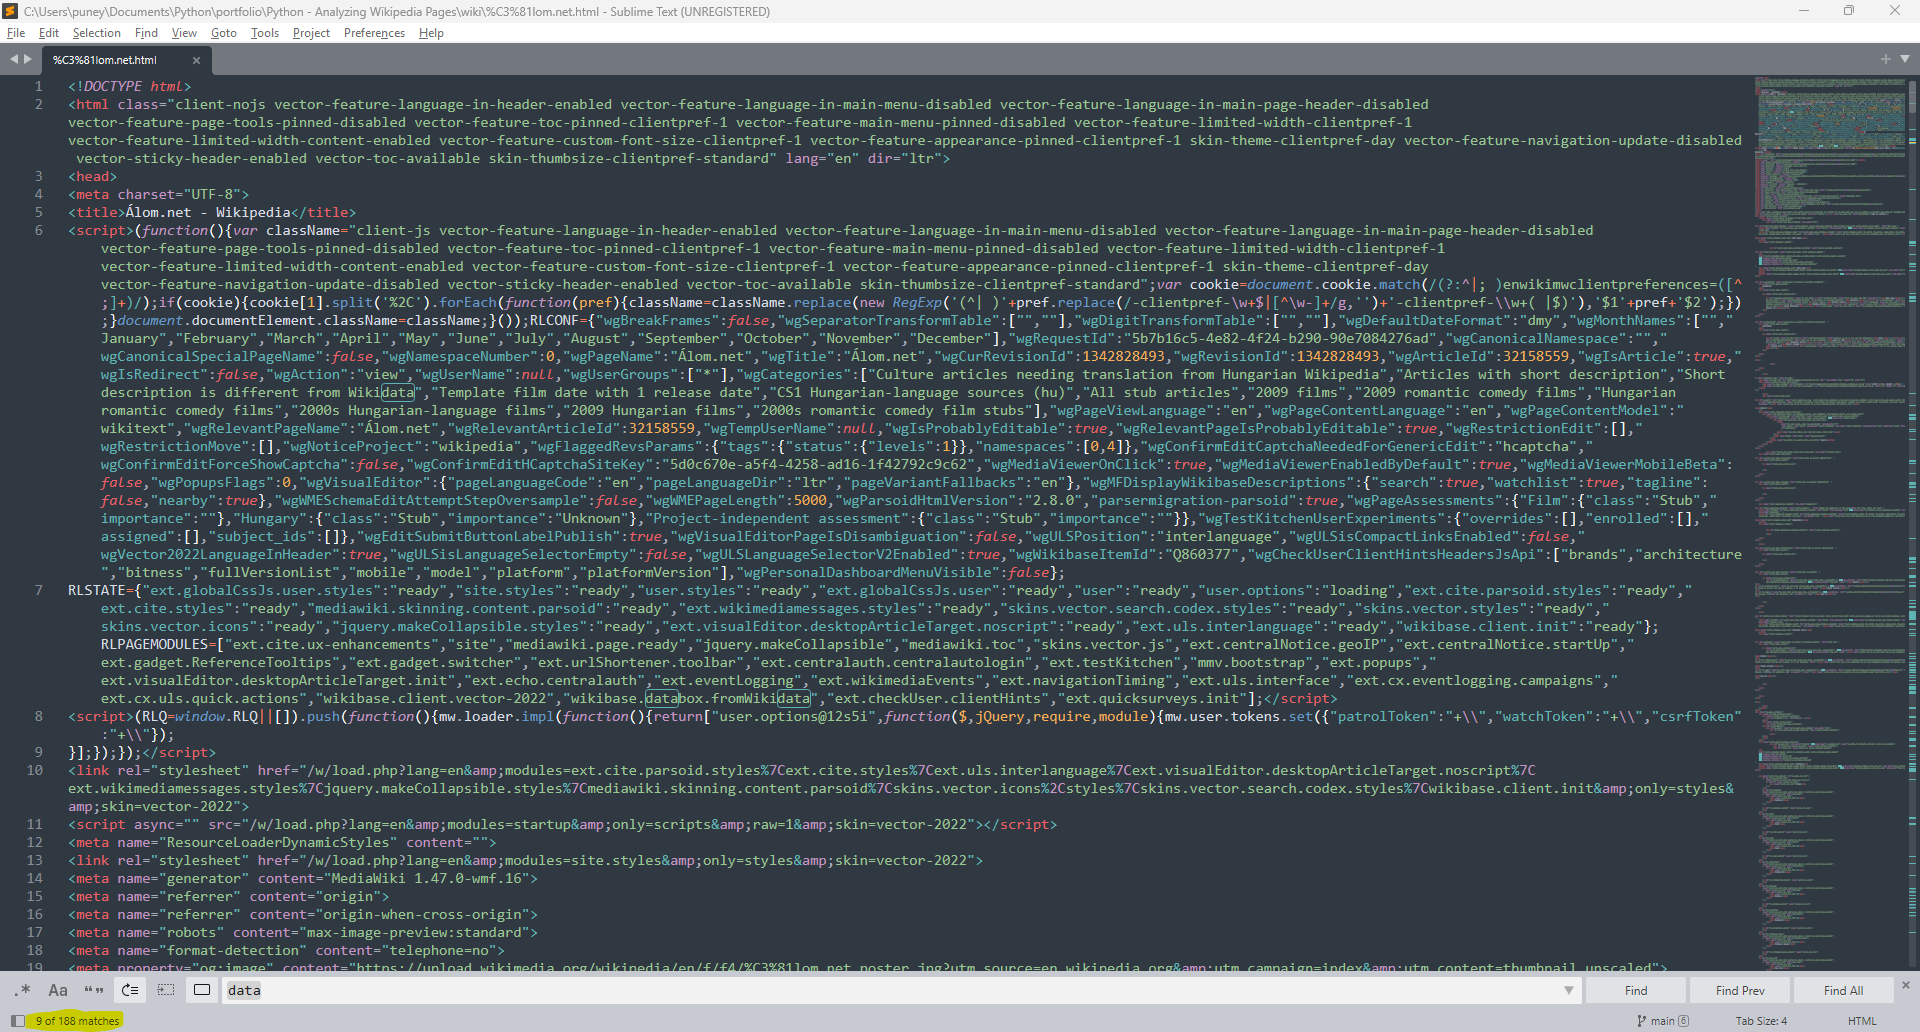

In [8]:
%%writefile grep_caseless_mapreduce.py
#homemade_grep_caseless
import os

def grep_mapper_caseless(data):
    target_word = "data"
    line_index={}
    for file in data:
        with open(os.path.join("wiki", file), encoding="UTF-8") as f:
            lines = [line for line in f.readlines()]
            for i in range(len(lines)):
                if target_word in lines[i].lower():
                    if file not in line_index:
                        line_index[file]=[]
                    line_index[file].append(i)

    return line_index

def grep_reducer_caseless(lines1, lines2):
    lines1.update(lines2)
    return lines1

Overwriting grep_caseless_mapreduce.py


In [16]:
from itertools import islice
import grep_caseless_mapreduce
importlib.reload(grep_caseless_mapreduce)
from grep_caseless_mapreduce import grep_mapper_caseless, grep_reducer_caseless

def make_chunks(data, num_chunks):
    chunk_size = math.ceil(len(data) / num_chunks)
    return [data[i:i+chunk_size] for i in range(0, len(data), chunk_size)]

def map_reduce(data, num_processes, mapper, reducer, chunk_size=100):
    chunks = make_chunks(data, chunk_size)
    with Pool(num_processes) as pool:
        results = list(pool.imap(mapper, chunks))
    return functools.reduce(reducer, results) if results else {}

if __name__ == "__main__":
    workers = (os.cpu_count() // 3) * 2
    caseless_occurence_list = map_reduce(files, workers, grep_mapper_caseless, grep_reducer_caseless)

    print(f"To verify this has executed correctly, we will load ten rows of the dictionary: \n")
    for key, items in islice(caseless_occurence_list.items(), 10):
        if key not in occurence_list:
            print("Found", len(items), "on file", key)
        elif len(items) >= len(occurence_list[key]):
            print("Found", (len(items)-len(occurence_list[key])), "additionally on file", key)

To verify this has executed correctly, we will load ten rows of the dictionary: 

Found 0 additionally on file %C3%81lom.net.html
Found 0 additionally on file %C3%81lvaro_of_C%C3%B3rdoba.html
Found 0 additionally on file %C3%81ngel_Garc%C3%ADa_%28basketball%2C_born_1988%29.html
Found 0 additionally on file %C3%81ngel_Malvicino.html
Found 0 additionally on file %C3%87%C4%B1nar_incident.html
Found 1 additionally on file %C3%87aml%C4%B1ca_Sports_Hall.html
Found 0 additionally on file %C3%87eltikli%2C_Bismil.html
Found 0 additionally on file %C3%87ukur%C3%B6z%2C_Divri%C4%9Fi.html
Found 0 additionally on file %C3%89lise_Crombez.html
Found 0 additionally on file %C3%89mile_Demangel.html
